# Fraud Detection Using Machine Learning
**Project:** 2023

End-to-end anomaly/fraud classification workflow with class imbalance, feature engineering, model training, evaluation, and a transaction-risk example.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
np.random.seed(42)
X,y = make_classification(n_samples=12000,n_features=10,n_informative=7,n_redundant=2,
                          weights=[.965,.035],class_sep=1.25,random_state=42)
cols=["amount","transaction_velocity","merchant_risk","device_risk","location_risk",
      "account_age","hour","failed_attempts","avg_amount_7d","distance_from_home"]
df=pd.DataFrame(X,columns=cols)
df["amount"]=np.abs(df["amount"]*180+90)
df["transaction_velocity"]=np.abs(df["transaction_velocity"]*3+2)
df["merchant_risk"]=1/(1+np.exp(-df["merchant_risk"]))
df["device_risk"]=1/(1+np.exp(-df["device_risk"]))
df["location_risk"]=1/(1+np.exp(-df["location_risk"]))
df["hour"]=np.mod((df["hour"]*6+12),24)
df["Fraud"]=y
print("Dataset:",df.shape," | Fraud rate:",f"{df.Fraud.mean():.2%}")
display(df.head())

Dataset: (12000, 11)  | Fraud rate: 4.01%


,amount,transaction_velocity,merchant_risk,device_risk,location_risk,account_age,hour,failed_attempts,avg_amount_7d,distance_from_home,Fraud
0,635.059215,1.074711,0.679837,0.188178,0.412261,-0.073473,9.887564,2.336286,0.465958,-2.663310,0
1,365.664843,4.350512,0.296323,0.199072,0.320091,-0.779888,11.840214,2.734310,0.234714,-3.166566,0
2,220.396393,5.668963,0.657555,0.453774,0.723982,0.553938,14.020765,2.621268,2.147736,-0.733063,0
3,123.710477,3.611711,0.007943,0.872035,0.584459,-1.892676,23.543852,2.281895,-0.976324,-0.267863,0
4,444.376143,1.819604,0.026323,0.539209,0.073754,-1.953582,4.251619,2.416520,-0.964629,-3.113890,0


In [ ]:
X=df.drop(columns="Fraud"); y=df.Fraud
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,stratify=y,random_state=42)
models={
 "Logistic Regression":Pipeline([("scale",StandardScaler()),("model",LogisticRegression(class_weight="balanced",max_iter=1000))]),
 "Random Forest":RandomForestClassifier(n_estimators=250,class_weight="balanced",random_state=42,n_jobs=-1)
}
for name,m in models.items():
    m.fit(X_train,y_train)
    p=m.predict(X_test); s=m.predict_proba(X_test)[:,1]
    print("\n",name)
    print(classification_report(y_test,p,digits=3))
    print("ROC-AUC:",round(roc_auc_score(y_test,s),4)," PR-AUC:",round(average_precision_score(y_test,s),4))


 Logistic Regression
              precision    recall  f1-score   support

           0      0.990     0.809     0.890      2880
           1      0.150     0.808     0.253       120

    accuracy                          0.809      3000
   macro avg      0.570     0.809     0.571      3000
weighted avg      0.957     0.809     0.865      3000

ROC-AUC: 0.8824  PR-AUC: 0.3503



 Random Forest
              precision    recall  f1-score   support

           0      0.977     1.000     0.988      2880
           1      0.981     0.442     0.609       120

    accuracy                          0.977      3000
   macro avg      0.979     0.721     0.799      3000
weighted avg      0.977     0.977     0.973      3000

ROC-AUC: 0.9274  PR-AUC: 0.749


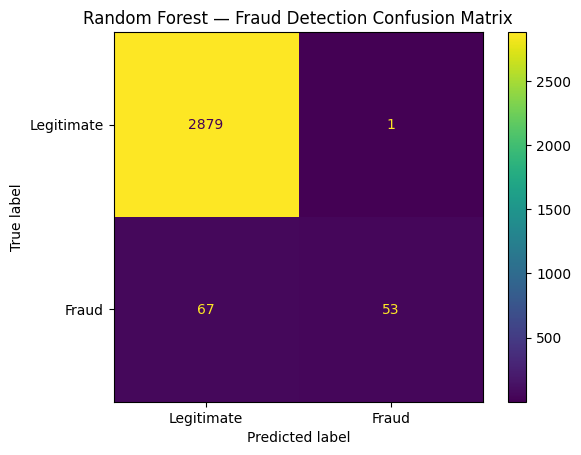

,importance
distance_from_home,0.3469
device_risk,0.1141
failed_attempts,0.1034
avg_amount_7d,0.0821
location_risk,0.0773
merchant_risk,0.0741
amount,0.0704
account_age,0.0582


In [ ]:
rf=models["Random Forest"]
pred=rf.predict(X_test)
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm,display_labels=["Legitimate","Fraud"]).plot()
plt.title("Random Forest — Fraud Detection Confusion Matrix")
plt.show()

importance=pd.Series(rf.feature_importances_,index=cols).sort_values(ascending=False)
display(importance.head(8).to_frame("importance").round(4))

In [ ]:
sample=X_test.iloc[[0]].copy()
score=rf.predict_proba(sample)[0,1]
print("Example transaction fraud probability:",f"{score:.2%}")
print("Decision:", "Flag for review" if score>=.50 else "Allow / monitor")

Example transaction fraud probability: 0.00%
Decision: Allow / monitor
